In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Load the dataset
df = pd.read_csv("Customer_Purchase_Data.csv")
print("First 5 rows of data:")
df.head()

First 5 rows of data:


,Age,Gender,AnnualIncome,SpendingScore,MaritalStatus,Purchased
0,25,Male,35000,60,Single,1
1,32,Female,48000,45,Married,0
2,28,Male,52000,75,Single,1
3,45,Female,65000,30,Married,0
4,35,Male,58000,85,Married,1


In [ ]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
             Age  AnnualIncome  SpendingScore  Purchased
count  20.000000     20.000000      20.000000  20.000000
mean   36.750000  55550.000000      55.950000   0.600000
std     8.878567  12721.614429      21.456136   0.502625
min    24.000000  34000.000000      20.000000   0.000000
25%    29.750000  46500.000000      38.750000   0.000000
50%    35.500000  57000.000000      57.500000   1.000000
75%    42.750000  63500.000000      72.750000   1.000000
max    55.000000  80000.000000      90.000000   1.000000


In [ ]:
print("\nHow many customers purchased?")
print(df["Purchased"].value_counts())


How many customers purchased?
Purchased
1    12
0     8
Name: count, dtype: int64


In [ ]:
# Check for missing (null) values
print("\nMissing values in each column:")
print(df.isnull().sum())


Missing values in each column:
Age              0
Gender           0
AnnualIncome     0
SpendingScore    0
MaritalStatus    0
Purchased        0
dtype: int64


In [ ]:
numeric_cols = df.select_dtypes(include="number").columns
cols_with_missing = [col for col in numeric_cols if df[col].isnull().sum() > 0]
 
if cols_with_missing:
    print(f"\nNumeric columns with missing values: {cols_with_missing}")
    plt.figure()
    df[cols_with_missing].boxplot()
    plt.title("Boxplot of Numerical Columns with Missing Values")
    plt.ylabel("Value")
    plt.savefig("graph0_boxplot_missing_columns.png")
    plt.close()
    print("Saved boxplot as 'graph0_boxplot_missing_columns.png'")
else:
    print("\nNo missing values found in numeric columns — no boxplot needed.")
 


No missing values found in numeric columns — no boxplot needed.


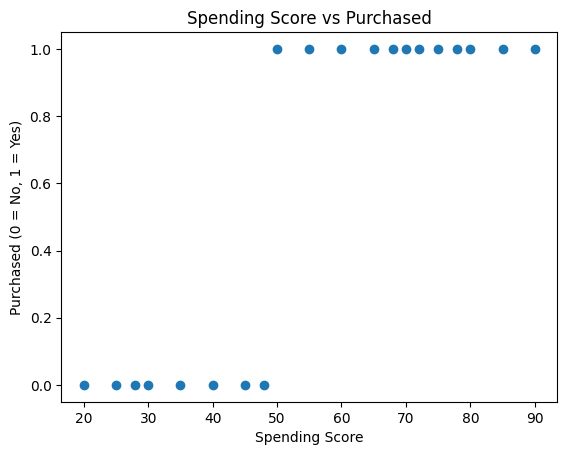

In [ ]:
# Visualizations
# 1) Scatter plot: Spending Score vs Purchased
plt.figure()
plt.scatter(df["SpendingScore"], df["Purchased"])
plt.xlabel("Spending Score")
plt.ylabel("Purchased (0 = No, 1 = Yes)")
plt.title("Spending Score vs Purchased")
plt.savefig("graph1_scatter_spending_vs_purchased.png")
plt.show()
plt.close()


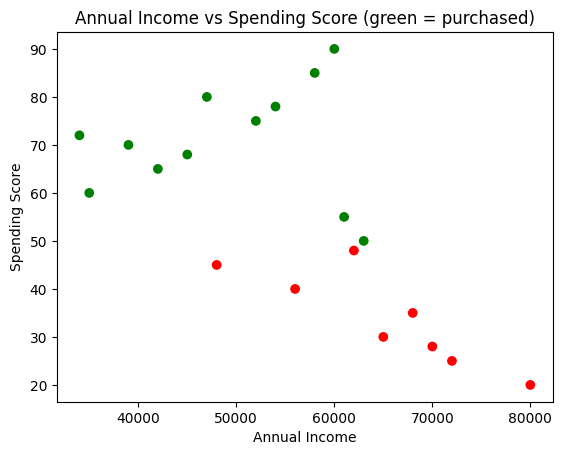

In [ ]:
# 2) Scatter plot: Annual Income vs Spending Score
plt.figure()
colors = df["Purchased"].map({0: "red", 1: "green"})
plt.scatter(df["AnnualIncome"], df["SpendingScore"], c=colors)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Annual Income vs Spending Score (green = purchased)")
plt.savefig("graph2_scatter_income_vs_spending.png")
plt.show()
plt.close()

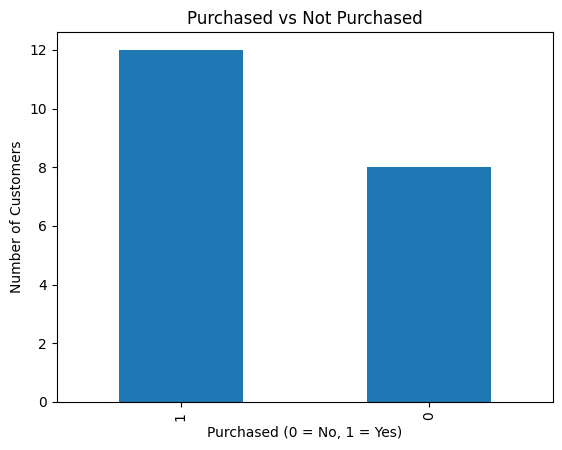

In [ ]:
 
# 3) Bar chart: How many purchased vs not purchased
plt.figure()
df["Purchased"].value_counts().plot(kind="bar")
plt.xlabel("Purchased (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.title("Purchased vs Not Purchased")
plt.savefig("graph3_bar_purchase_counts.png")
plt.show()
plt.close()

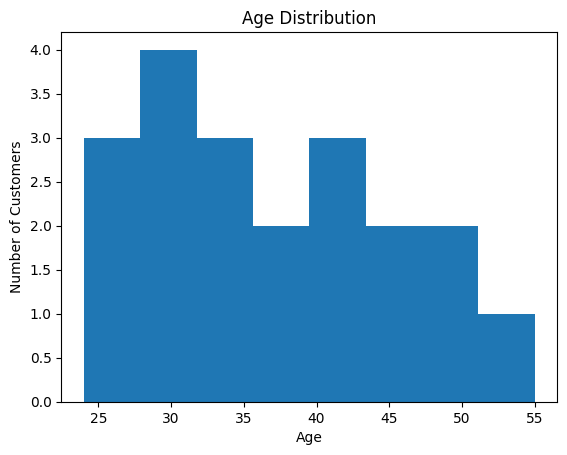

In [ ]:
# 4) Histogram: Age distribution
plt.figure()
plt.hist(df["Age"], bins=8)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Age Distribution")
plt.savefig("graph4_histogram_age.png")
plt.show()
plt.close()

In [ ]:
print("\nSaved 4 graphs as PNG files:")
print("  graph1_scatter_spending_vs_purchased.png")
print("  graph2_scatter_income_vs_spending.png")
print("  graph3_bar_purchase_counts.png")
print("  graph4_histogram_age.png")


Saved 4 graphs as PNG files:
  graph1_scatter_spending_vs_purchased.png
  graph2_scatter_income_vs_spending.png
  graph3_bar_purchase_counts.png
  graph4_histogram_age.png


In [ ]:
# Prepare the data for the model
# Convert "Male"/"Female" and "Single"/"Married" into 0s and 1s.
df_model = df.copy()
df_model["Gender"] = df_model["Gender"].map({"Male": 0, "Female": 1})
df_model["MaritalStatus"] = df_model["MaritalStatus"].map({"Single": 0, "Married": 1})

# Select features (X) and target variable (y)
X = df_model[["Age", "Gender", "AnnualIncome", "SpendingScore", "MaritalStatus"]]
y = df_model["Purchased"]

In [ ]:
df_model.head()

,Age,Gender,AnnualIncome,SpendingScore,MaritalStatus,Purchased
0,25,0,35000,60,0,1
1,32,1,48000,45,1,0
2,28,0,52000,75,0,1
3,45,1,65000,30,1,0
4,35,0,58000,85,1,1


In [ ]:
# Splitting data:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Try a couple of simple models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
}
print("\nComparing models:")
best_name = None
best_model = None
best_accuracy = 0
 
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"  {name}: {accuracy * 100:.0f}% accuracy")
 
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_name = name
        best_model = model
 
print(f"\nBest model: {best_name} ({best_accuracy * 100:.0f}% accuracy)")


Comparing models:
  Logistic Regression: 67% accuracy
  Decision Tree: 83% accuracy

Best model: Decision Tree (83% accuracy)


In [ ]:
# Re-train the best model on ALL the data
best_model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Save the best model to a file
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
 
print("\nSaved the best model to 'best_model.pkl'.")
#print("Now run: streamlit run app.py")


Saved the best model to 'best_model.pkl'.
